## Mini-Project 1: UBOS District Population Forecaster

**Scenario.** A district planning unit wants 5-year population forecasts (2025-2029) to plan primary school classrooms, using 10 years of illustrative population estimates (in thousands), 2015-2024.



This notebook uses the `DistrictPopulation` class and `Forecaster` subclasses defined in `src/project1_population.py`.

In [1]:
import math
import sys

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, "../src")
from project1_population import (
    CAGRForecaster,
    DistrictPopulation,
    FibonacciRatioForecaster,
    LinearTrendForecaster,
)
from utils import mae, mape, rmse

np.random.seed(42)

### Tasks 1-3: district data, descriptive statistics, growth and CAGR

Two illustrative districts (Mbale, Arua) are added alongside the three supplied districts. `statistics.variance` uses `ddof=1` (sample variance); `np.var` defaults to `ddof=0` (population variance) unless `ddof=1` is passed, which is why the two only agree once `ddof=1` is used for both.

In [2]:
years = list(range(2015, 2025))

district_data = {
    "Kampala": [1200, 1250, 1300, 1350, 1420, 1500, 1580, 1650, 1720, 1800],
    "Wakiso": [950, 1000, 1070, 1150, 1220, 1300, 1390, 1480, 1570, 1670],
    "Gulu": [320, 330, 345, 360, 375, 390, 410, 430, 455, 480],
    # Illustrative extra districts (not sourced from UBOS), added for this assignment
    "Mbale": [430, 440, 455, 470, 485, 500, 520, 540, 560, 585],
    "Arua": [280, 290, 300, 312, 325, 340, 355, 372, 390, 410],
}

districts = {name: DistrictPopulation(name, years, pops) for name, pops in district_data.items()}

for district in districts.values():
    print(repr(district), "len:", len(district))

print("\n-- Descriptive statistics --")
for name, district in districts.items():
    stats = district.describe_statistics()
    print(f"\n{name}")
    for key, value in stats.items():
        print(f"  {key}: {value:.3f}")

print("\n-- Growth rates --")
cagr_table = {}
for name, district in districts.items():
    growth = district.year_on_year_growth()
    cagr_value = district.cagr()
    cagr_table[name] = cagr_value
    print(f"{name}: year-on-year growth % = {np.round(growth, 2)}, CAGR = {cagr_value:.4f}")

fastest = max(cagr_table, key=cagr_table.get)
print(f"\nFastest-growing district by CAGR: {fastest} ({cagr_table[fastest]:.4f})")

DistrictPopulation(name='Kampala', years=2015-2024, n=10) len: 10
DistrictPopulation(name='Wakiso', years=2015-2024, n=10) len: 10
DistrictPopulation(name='Gulu', years=2015-2024, n=10) len: 10
DistrictPopulation(name='Mbale', years=2015-2024, n=10) len: 10
DistrictPopulation(name='Arua', years=2015-2024, n=10) len: 10

-- Descriptive statistics --

Kampala
  statistics_mean: 1477.000
  statistics_median: 1460.000
  statistics_variance: 42601.111
  statistics_stdev: 206.400
  numpy_mean: 1477.000
  numpy_var_ddof0: 38341.000
  numpy_var_ddof1: 42601.111
  numpy_std_ddof1: 206.400

Wakiso
  statistics_mean: 1280.000
  statistics_median: 1260.000
  statistics_variance: 60066.667
  statistics_stdev: 245.085
  numpy_mean: 1280.000
  numpy_var_ddof0: 54060.000
  numpy_var_ddof1: 60066.667
  numpy_std_ddof1: 245.085

Gulu
  statistics_mean: 389.500
  statistics_median: 382.500
  statistics_variance: 2885.833
  statistics_stdev: 53.720
  numpy_mean: 389.500
  numpy_var_ddof0: 2597.250
  numpy

### Tasks 4-6: forecasting models, walk-forward validation, 2025-2029 forecast

Three `Forecaster` subclasses (linear trend, CAGR growth, Fibonacci ratio) are trained on 2015-2021 and tested on 2022-2024. The model with the lowest RMSE per district is refit on the full 2015-2024 series and used to forecast 2025-2029.

In [3]:
model_classes = {
    "Linear trend": LinearTrendForecaster,
    "CAGR growth": CAGRForecaster,
    "Fibonacci ratio": FibonacciRatioForecaster,
}

train_years, test_years = np.array(years[:7]), np.array(years[7:])
best_model_name = {}

for name, district in districts.items():
    train_pop, test_pop = district.populations[:7], district.populations[7:]
    print(f"\n{name}")
    scores = {}
    for model_name, model_cls in model_classes.items():
        model = model_cls()
        model.fit(train_years, train_pop)
        predicted = model.predict(len(test_years))
        scores[model_name] = {
            "MAE": mae(test_pop, predicted),
            "RMSE": rmse(test_pop, predicted),
            "MAPE": mape(test_pop, predicted),
        }
        print(f"  {model_name}: MAE={scores[model_name]['MAE']:.2f}, "
              f"RMSE={scores[model_name]['RMSE']:.2f}, MAPE={scores[model_name]['MAPE']:.2f}%")
    best_model_name[name] = min(scores, key=lambda m: scores[m]["RMSE"])
    print(f"  -> best model (lowest RMSE): {best_model_name[name]}")

forecast_horizon = 5
forecasts = {}

print("\n-- 2025-2029 forecasts with selected model --")
for name, district in districts.items():
    model = model_classes[best_model_name[name]]()
    model.fit(district.years, district.populations)
    forecast_values = model.predict(forecast_horizon)
    forecasts[name] = forecast_values
    actual_var = np.var(district.populations, ddof=1)
    forecast_var = np.var(forecast_values, ddof=1)
    print(f"{name} ({best_model_name[name]}): forecast = {np.round(forecast_values, 1)}")
    print(f"  actual variance = {actual_var:.1f}, forecast variance = {forecast_var:.1f}")


Kampala
  Linear trend: MAE=37.62, RMSE=38.97, MAPE=2.17%
  CAGR growth: MAE=9.62, RMSE=10.39, MAPE=0.55%
  Fibonacci ratio: MAE=997.78, RMSE=1064.12, MAPE=58.53%
  -> best model (lowest RMSE): CAGR growth

Wakiso
  Linear trend: MAE=49.40, RMSE=52.37, MAPE=3.09%
  CAGR growth: MAE=6.80, RMSE=8.05, MAPE=0.42%
  Fibonacci ratio: MAE=820.56, RMSE=889.46, MAPE=53.12%
  -> best model (lowest RMSE): CAGR growth

Gulu
  Linear trend: MAE=18.57, RMSE=20.29, MAPE=4.01%
  CAGR growth: MAE=9.44, RMSE=10.87, MAPE=2.02%
  Fibonacci ratio: MAE=251.11, RMSE=270.21, MAPE=56.07%
  -> best model (lowest RMSE): CAGR growth

Mbale
  Linear trend: MAE=15.24, RMSE=16.46, MAPE=2.68%
  CAGR growth: MAE=7.47, RMSE=8.56, MAPE=1.31%
  Fibonacci ratio: MAE=333.89, RMSE=354.84, MAPE=60.01%
  -> best model (lowest RMSE): CAGR growth

Arua
  Linear trend: MAE=13.60, RMSE=14.60, MAPE=3.43%
  CAGR growth: MAE=6.24, RMSE=6.98, MAPE=1.57%
  Fibonacci ratio: MAE=220.72, RMSE=236.33, MAPE=57.24%
  -> best model (lowest 

### Task 7: Visualisation

Actual, fitted-on-test and forecast values for every district, with the train/test split marked.

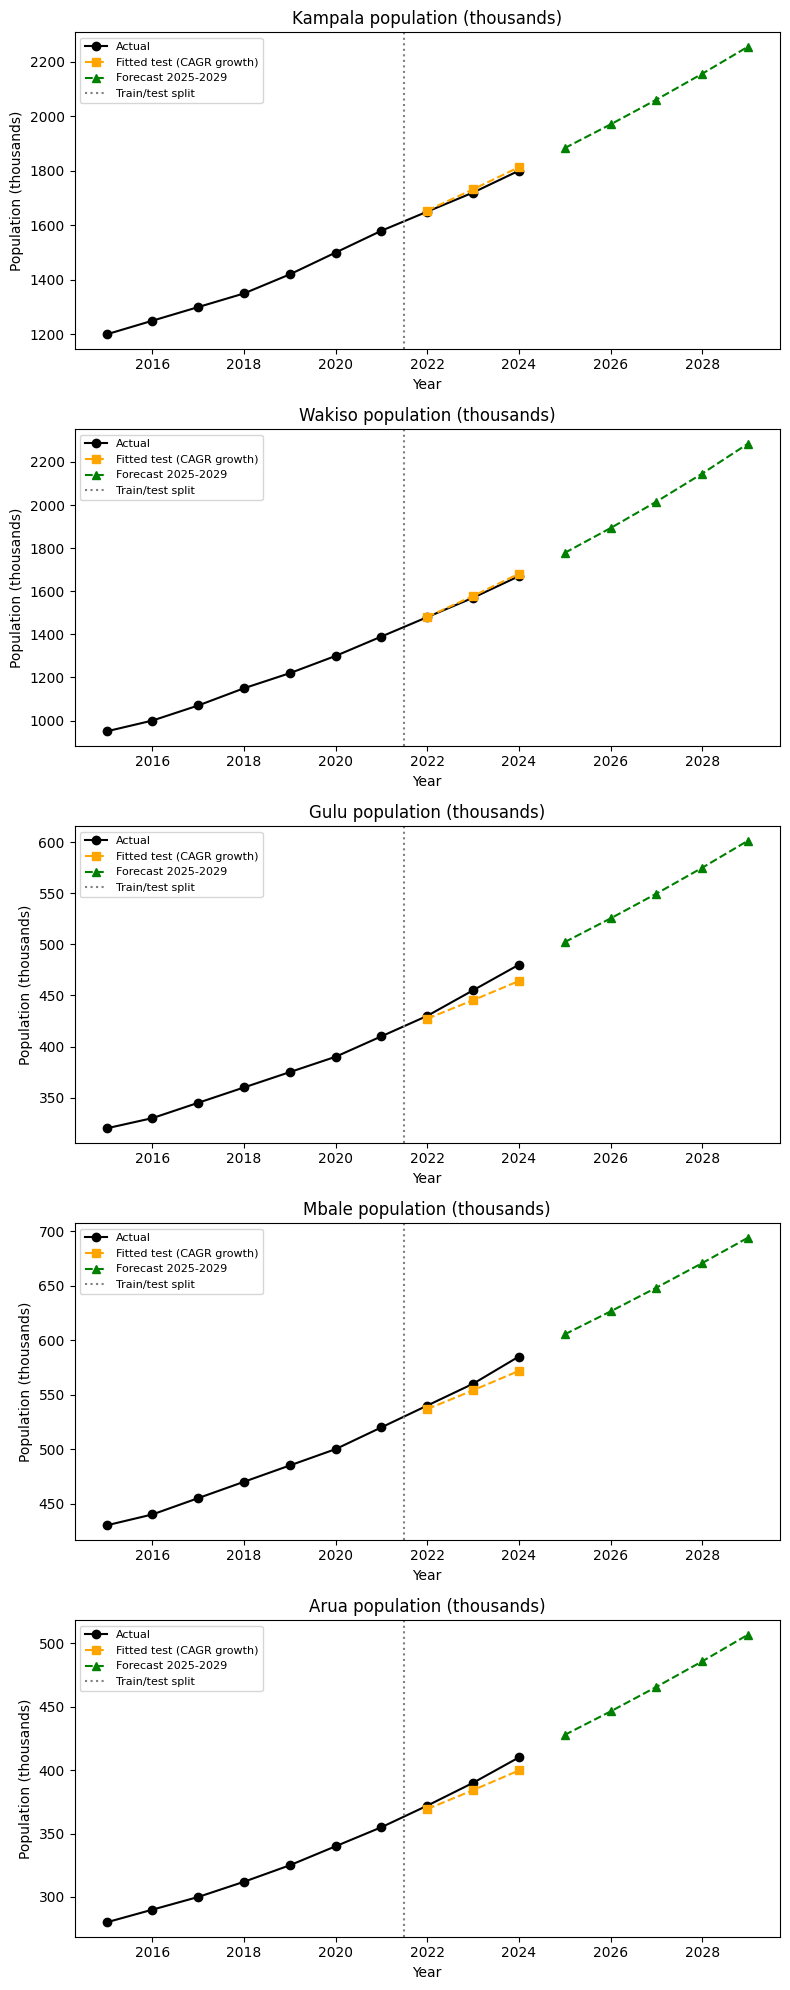

In [4]:
fig, axes = plt.subplots(len(districts), 1, figsize=(8, 4 * len(districts)))

for ax, (name, district) in zip(axes, districts.items()):
    train_pop, test_pop = district.populations[:7], district.populations[7:]
    best_model = model_classes[best_model_name[name]]()
    best_model.fit(train_years, train_pop)
    fitted_test = best_model.predict(len(test_years))

    ax.plot(years, district.populations, "o-", color="black", label="Actual")
    ax.plot(test_years, fitted_test, "s--", color="orange", label=f"Fitted test ({best_model_name[name]})")
    future_years = np.arange(years[-1] + 1, years[-1] + 1 + forecast_horizon)
    ax.plot(future_years, forecasts[name], "^--", color="green", label="Forecast 2025-2029")
    ax.axvline(train_years[-1] + 0.5, color="grey", linestyle=":", label="Train/test split")
    ax.set_title(f"{name} population (thousands)")
    ax.set_xlabel("Year")
    ax.set_ylabel("Population (thousands)")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### Task 8: Planning output - additional classrooms needed by 2029

Assumes 18% of the population is primary-school age and one classroom holds 53 pupils.

In [5]:
PRIMARY_SHARE = 0.18
PUPILS_PER_CLASSROOM = 53

print(f"{'District':<10} {'2024 (000s)':>12} {'2029 (000s)':>12} {'Additional classrooms':>22}")
for name, district in districts.items():
    pop_2024 = district.populations[-1]
    pop_2029 = forecasts[name][-1]
    classrooms_2024 = math.ceil(PRIMARY_SHARE * pop_2024 * 1000 / PUPILS_PER_CLASSROOM)
    classrooms_2029 = math.ceil(PRIMARY_SHARE * pop_2029 * 1000 / PUPILS_PER_CLASSROOM)
    additional = classrooms_2029 - classrooms_2024
    print(f"{name:<10} {pop_2024:>12.1f} {pop_2029:>12.1f} {additional:>22d}")

District    2024 (000s)  2029 (000s)  Additional classrooms
Kampala          1800.0       2254.8                   1544
Wakiso           1670.0       2284.7                   2088
Gulu              480.0        601.3                    412
Mbale             585.0        694.1                    371
Arua              410.0        506.8                    329


## Findings & Limitations

Across all five districts, the CAGR growth model had the lowest RMSE on the 2022-2024 test years, clearly beating the linear trend and the Fibonacci-ratio model. The Fibonacci-ratio model was the worst by a wide margin (MAPE around 53-60%), confirming it is not a sound population model: its ratios are fixed by a number sequence and have no link to the district's actual growth rate. Wakiso was the fastest-growing district in relative terms (CAGR 6.47%), even though Kampala adds more people in absolute thousands each year - a good example of why CAGR, not raw year-on-year change, is the right measure of "fastest growing". For every district, forecast variance (2025-2029) was noticeably lower than the historical actual variance, because a constant-rate CAGR model produces a smooth curve without the small yearly fluctuations present in the real 10-year series; this understates future uncertainty. The planning table shows Wakiso and Kampala needing the most additional classrooms by 2029 (2,088 and 1,544 respectively), reflecting both their large populations and above-average growth rates.

**Limitations:** all population figures are illustrative, not official UBOS statistics, including the two added districts (Mbale, Arua). A constant CAGR is unrealistic over a long horizon since real growth typically decelerates as districts urbanise. No prediction intervals were produced (the optional bootstrap extension was not implemented in this notebook), so the 2029 forecasts should be read as point estimates only, not guaranteed outcomes.